# PF Analysis

Load PF analysis summaries and generate the paper-ready grid plus a standalone horizontal legend.

In [6]:
from pathlib import Path
import json
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / "save").exists() and (path / "test_notebooks").exists():
            return path
    raise FileNotFoundError("Could not find the project root containing save/ and test_notebooks/.")


PROJECT_ROOT = find_project_root()
SAVE_ROOT = PROJECT_ROOT / "save"
FIG_DIR = SAVE_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = [
    {
        "folder": "pf_analysis_doubling1d_cos2pi",
        "title": "Doubling-Angle\n(Cosine)",
    },
    {
        "folder": "pf_analysis_lorenz63_identity",
        "title": "Lorenz '63\n(identity)",
    },
    {
        "folder": "pf_analysis_lorenz63_square",
        "title": "Lorenz '63\n(square)",
    },
    {
        "folder": "pf_analysis_lorenz63_arctan",
        "title": "Lorenz '63\n(arctan)",
    },
]

METRICS = {
    "mean_ess_mean": "ESS",
    "mean_weight_abundance_mean": "Weight Abundance",
    "se_mean_elementwise_avg": "Mean SE",
    "se_cov_elementwise_avg": "Cov SE",
}

STYLE = {
    "mean_ess_mean": {"color": "#1f77b4", "marker": "o", "linestyle": "-"},
    "mean_weight_abundance_mean": {"color": "#d62728", "marker": "s", "linestyle": "--"},
    "se_mean_elementwise_avg": {"color": "#2ca02c", "marker": "o", "linestyle": "-"},
    "se_cov_elementwise_avg": {"color": "#9467bd", "marker": "s", "linestyle": "--"},
}

mpl.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 28,
    "axes.labelsize": 28,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 26,
    "lines.linewidth": 3.4,
    "lines.markersize": 9,
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def load_summary(folder):
    folder_path = SAVE_ROOT / folder
    json_files = sorted(folder_path.glob("*.json"))
    if len(json_files) != 1:
        raise FileNotFoundError(f"Expected exactly one JSON file in {folder_path}, found {len(json_files)}.")

    with json_files[0].open("r") as f:
        payload = json.load(f)

    available_m = np.asarray(payload["available_M"], dtype=float)
    order = np.argsort(available_m)
    available_m = available_m[order]

    series = {}
    for metric in METRICS:
        values = np.asarray([
            payload["analysis"][str(int(m))][metric]
            for m in available_m
        ], dtype=float)
        series[metric] = values

    return {
        "path": json_files[0],
        "M": available_m,
        "series": series,
    }


results = {item["folder"]: load_summary(item["folder"]) for item in DATASETS}
for item in DATASETS:
    loaded = results[item["folder"]]
    print(f"{item['title'].replace(chr(10), ' ')}: {loaded['path'].relative_to(PROJECT_ROOT)}")

Doubling-Angle (Cosine): save/pf_analysis_doubling1d_cos2pi/summary_sigma_0.2_batch_64_len_200.json
Lorenz '63 (identity): save/pf_analysis_lorenz63_identity/summary_sigma_2.0_batch_64_len_500.json
Lorenz '63 (square): save/pf_analysis_lorenz63_square/summary_sigma_16.97_batch_64_len_500.json
Lorenz '63 (arctan): save/pf_analysis_lorenz63_arctan/summary_sigma_0.32_batch_64_len_500.json


Saved save/figures/pf_analysis_grid.pdf
Saved save/figures/pf_analysis_grid.png


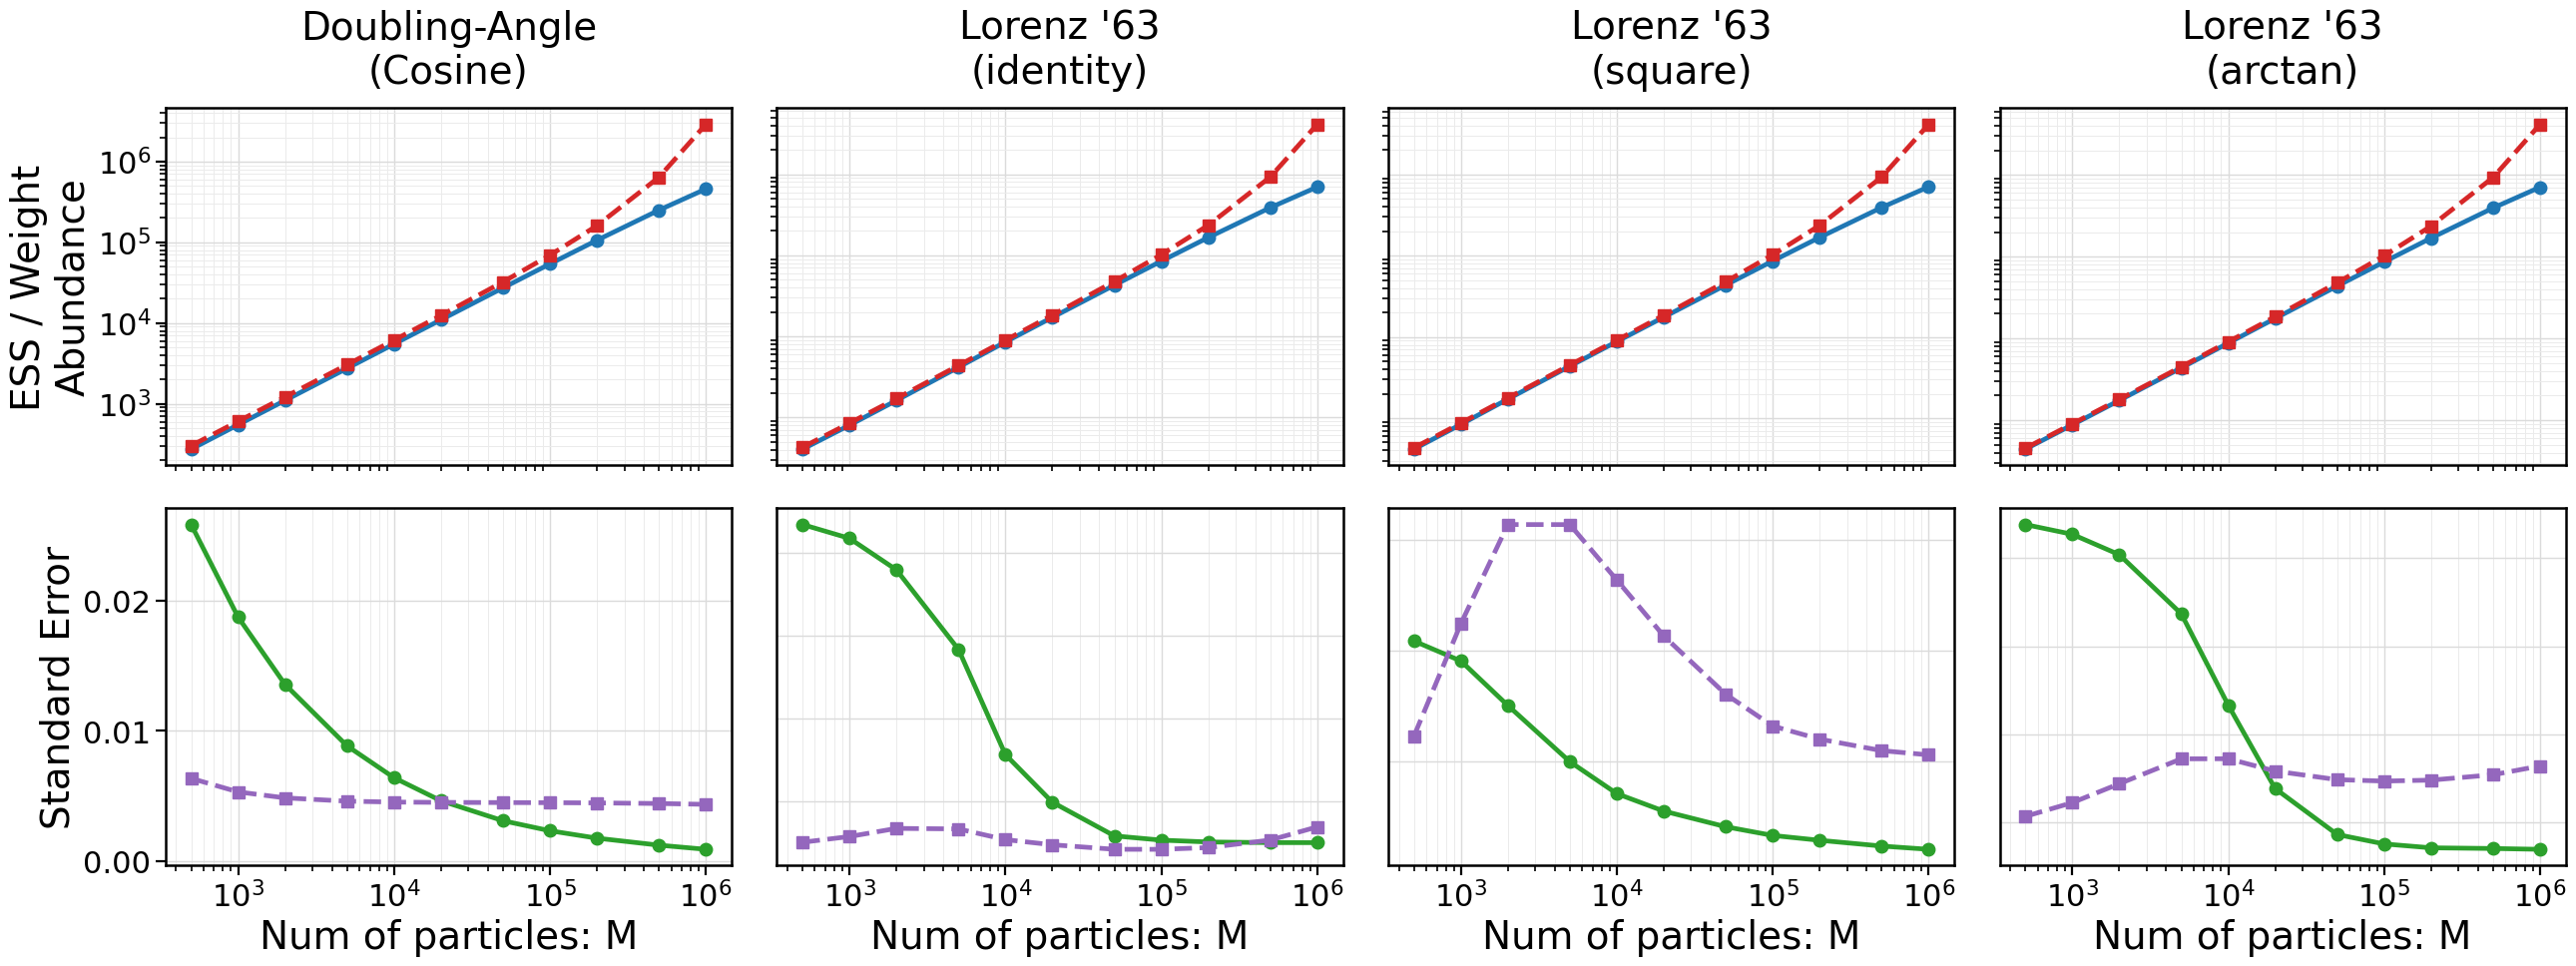

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(26, 11), sharex="col")

top_metrics = ["mean_ess_mean", "mean_weight_abundance_mean"]
bottom_metrics = ["se_mean_elementwise_avg", "se_cov_elementwise_avg"]

for col, item in enumerate(DATASETS):
    loaded = results[item["folder"]]
    M = loaded["M"]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    for metric in top_metrics:
        ax_top.plot(M, loaded["series"][metric], **STYLE[metric])
    for metric in bottom_metrics:
        ax_bottom.plot(M, loaded["series"][metric], **STYLE[metric])

    ax_top.set_title(item["title"], pad=18)
    ax_top.set_xscale("log")
    ax_top.set_yscale("log")
    ax_bottom.set_xscale("log")
    ax_bottom.set_yscale("linear")

    for ax in (ax_top, ax_bottom):
        ax.grid(True, which="major", color="0.86", linewidth=1.0)
        ax.grid(True, which="minor", color="0.92", linewidth=0.7)
        ax.tick_params(axis="both", which="major", length=7)
        ax.tick_params(axis="both", which="minor", length=4)

    if col != 0:
        ax_top.tick_params(axis="y", left=False, labelleft=False)
        ax_bottom.tick_params(axis="y", left=False, labelleft=False)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

axes[0, 0].set_ylabel("ESS / Weight\nAbundance")
axes[1, 0].set_ylabel("Standard Error")
for ax in axes[1, :]:
    ax.set_xlabel("Num of particles: M")

fig.subplots_adjust(left=0.07, right=0.995, bottom=0.13, top=0.82, wspace=0.08, hspace=0.12)

grid_pdf = FIG_DIR / "pf_analysis_grid.pdf"
grid_png = FIG_DIR / "pf_analysis_grid.png"
fig.savefig(grid_pdf, bbox_inches="tight", pad_inches=0.06)
fig.savefig(grid_png, dpi=300, bbox_inches="tight", pad_inches=0.06)

print(f"Saved {grid_pdf.relative_to(PROJECT_ROOT)}")
print(f"Saved {grid_png.relative_to(PROJECT_ROOT)}")
plt.show()

Saved save/figures/pf_analysis_legend.pdf
Saved save/figures/pf_analysis_legend.png


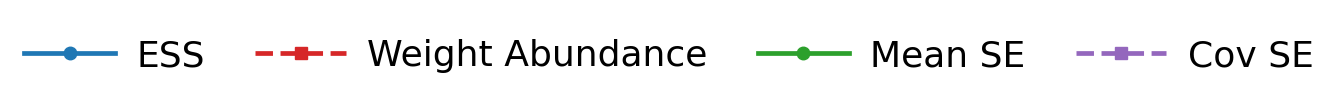

In [9]:
legend_handles = [
    Line2D([0], [0], label=label, **STYLE[metric])
    for metric, label in METRICS.items()
]

fig_legend, ax_legend = plt.subplots(figsize=(14, 1.2))
ax_legend.axis("off")
ax_legend.legend(
    handles=legend_handles,
    loc="center",
    ncol=4,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.4,
    handletextpad=0.6,
)

legend_pdf = FIG_DIR / "pf_analysis_legend.pdf"
legend_png = FIG_DIR / "pf_analysis_legend.png"
fig_legend.savefig(legend_pdf, bbox_inches="tight", pad_inches=0.02)
fig_legend.savefig(legend_png, dpi=300, bbox_inches="tight", pad_inches=0.02)

print(f"Saved {legend_pdf.relative_to(PROJECT_ROOT)}")
print(f"Saved {legend_png.relative_to(PROJECT_ROOT)}")
plt.show()